In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import f_oneway, kruskal
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from itertools import product 
from time import time
import seaborn as sns
import matplotlib.pyplot as plt

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config
import hyp_config
from utils.analysis import get_query_string_hyps_filter, load_dbscan_labels

# Feature Importance Analysis
&#8594; Determine whether the mean values of the scaled parameters differ significantly across clusters 

In [3]:
# Load data
df_in = pd.read_csv(f"{config.output_dir}wide_table_knn.csv") 
df = df_in.drop(["LATITUDE", "LONGITUDE", "LEV_M", "imputed", "water"], axis=1)  # Remove unneeded information

In [4]:
# Scale data
scaler = MinMaxScaler().fit(df)
df_scaled = pd.DataFrame(scaler.transform(df), columns=df.columns)

# Combine dataframes
df_total = df_in.copy()
for p in ["P_TEMPERATURE", "P_SALINITY", "P_OXYGEN", "P_NITRATE", "P_SILICATE", "P_PHOSPHATE"]:
    df_total[p + "_scaled"] = df_scaled[p]

In [5]:
# Load clustering results
#df_kmeans = pd.read_csv(f"{config.output_dir_clustering}/labels_kmeans.csv")
#df_ward = pd.read_csv(f"{config.output_dir_clustering}/labels_ward.csv")
#df_dbscan = pd.read_csv(f"{config.output_dir_clustering}/labels_dbscan_iteration0.csv")

In [6]:
# TEMPORARY TO DO REMOVE
# Load clustering results
# df_kmeans = pd.read_csv(f"output/clustering_old/labels_kmeans.csv")
# df_ward = pd.read_csv(f"output/clustering_old/labels_ward.csv")
# df_dbscan = pd.read_csv(f"output/clustering_old/labels_dbscan_iteration0.csv")

In [7]:
def rf(df, x_columns, y_column="label", max_depth=None):
    """ Train a random forest to mimic a clustering model. """
    X = df[x_columns]
    y = df[y_column]
    rf_results = []

    # Train a random forest
    rf_clf = RandomForestClassifier(random_state=42, 
                                    oob_score=True,
                                    verbose=True,
                                    #max_features=0.5,        # Control feature selection per split
                                    #min_samples_leaf=3,      # Avoid overfitting by limiting leaf size
                                    max_depth=max_depth,          # Allow deep trees for complex separations (but not too deep as there are some cases with high numbers of clusters)
                                    n_estimators=1000,        # More trees to improve robustness (some clusters are challenging to separate, small clusters)
                                    class_weight="balanced")  # Ensure that small clusters contribute equally to decision
    rf_clf.fit(X, y)
    
    # Get feature importance
    rf_importance = rf_clf.feature_importances_
    
    # Store results
    for param, importance in zip(X.columns, rf_importance):
        rf_results.append(pd.DataFrame({"parameter": [param], "importance": [importance], "oob": [rf_clf.oob_score_]}))

    return pd.concat(rf_results).sort_values("importance", ascending=False).reset_index(drop=True)

In [8]:
# Training and UMAP columns
x_cols = ['P_TEMPERATURE_scaled', 'P_SALINITY_scaled', 'P_OXYGEN_scaled', 'P_NITRATE_scaled', 'P_SILICATE_scaled', 'P_PHOSPHATE_scaled']
umap_cols = [f"e{i}" for i in range(hyp_config.umap_hyps["n_components"])]

## Compute feature importances

In [9]:
# def load_dbscan_label_as_df(iteration, preprocessing, hyps):
#     if iteration == 0:
#         query_str = get_query_string_hyps_filter(hyps, preproc=preprocessing) + f"& iteration=={iteration}"  
#         temp = load_dbscan_label_as_df(iteration=iteration, preprocessing=preprocessing, hyps=hyps)
#         temp = temp.query(query_str)[["label", "LATITUDE", "LONGITUDE", "LEV_M"]]
#     else:
#         cluster_name = "dbscan"
#         eps_array = config.algorithms_and_hyps["dbscan"][1]["eps"]
#         eps = eps_array[np.abs(eps_array - hyps["eps"]).argmin()]
#         min_samples = hyps["min_samples"]
        
#         filename = f"{config.output_dir_clustering}labels_iteration{iteration}_{preprocessing}_{cluster_name}_eps{eps}_min_samples{min_samples}.csv"
#         temp = pd.read_csv(filename)

#     return temp

In [10]:
def smart_max_depth(n_clusters, class_limit=400, multiplier=1.5, depth_cap=20):
    """ Define max_depth for the RandomForestClassifier in a ressource efficient way. """
    if n_clusters <= class_limit:
        max_depth = None
    else:
        max_depth = min(depth_cap, int(np.log2(n_clusters) * multiplier))
        
    return max_depth

In [ ]:
# Feature importance for all hyperparameter combinations
for cluster_name, (ClusterAlgo, param_grid) in config.algorithms_and_hyps.items():
    if cluster_name == "dbscan": 
        print(cluster_name)
        
        # Generate all hyperparameter combinations
        hyp_param_combinations = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]
    
        # Load data
        if cluster_name != "dbscan": 
            print(f"Load data for {cluster_name}...")
            data_file = f"{config.output_dir_clustering}/labels_{cluster_name}.csv"
            df_feature_importance = pd.read_csv(data_file)

        # Iterate over iterations
        for i in range(1, config.n_iterations): 
            print(f"  Iteration {i}")

            # For DBSCAN, we need to load each iteration separately
            if cluster_name == "dbscan": 
                print("    Loading DBSCAN data...")
                df_feature_importance = load_dbscan_labels(iteration=i) 
                # Ensure proper data types
                df_feature_importance["eps"] = df_feature_importance["eps"].astype(float)
                df_feature_importance["min_samples"] = df_feature_importance["min_samples"].astype(int)
        
            # Iterate over hyperparameter combinations
            for hyp_params in hyp_param_combinations:
                    
                filename = f"{config.output_dir_feature_importance}feature_importance_iteration{i}_{cluster_name}_{'_'.join([f'{k}{v}' for k, v in hyp_params.items()])}.csv"

                # Only compute relevant DBSCAN importances
                if cluster_name == "dbscan":
                    hyp_params["eps"] = np.round(hyp_params["eps"], 8)
                    if hyp_params != hyp_config.dbscan_original_hyps and hyp_params != hyp_config.dbscan_umap_hyps:
                        continue
                
                # Only compute if it has not been done before 
                if not Path(filename).exists():
                    print(f"    Now computing: {filename}")
                    res = []
                    
                    # Iterate over prepprocessings
                    for preprocessing in config.preprocessings.keys():    

                        # Get labels
                        start_time = time()
                        query_str = get_query_string_hyps_filter(hyp_params, preproc=preprocessing, iteration=i)    
                        temp = df_feature_importance.query(query_str)[["label", "LATITUDE", "LONGITUDE", "LEV_M"]]
    
                        # Add parameter information
                        temp = df_total.merge(temp, on=["LATITUDE", "LONGITUDE", "LEV_M"], how="outer")
    
                        # Train RF (for DBSCAN, we limit the max_depth since there are some cluster sets with >6000 labels)
                        max_depth = smart_max_depth(n_clusters=len(temp["label"].unique()), class_limit=500, multiplier=1.5, depth_cap=20)
                        print(f"    Max depth: {max_depth}\n    Number of clusters: {len(temp.label.unique())}")
                        # forest = rf(temp, x_columns=x_cols, max_depth=max_depth)
   
                        end_time = time()
    
                        # Append results
                        forest_dict = forest.to_dict()
                        forest_flat = [
                            {"parameter": forest_dict["parameter"][i],
                             "importance": forest_dict["importance"][i],
                             "oob": forest_dict["oob"][i]}
                            for i in forest_dict["parameter"]
                        ]
                        for row in forest_flat:
                            res.append({**{
                                "iteration": i,
                                "preprocessing": preprocessing,
                                "clustering": cluster_name,
                                "importance_time": end_time - start_time,
                            }, **hyp_params, **row})
    
                    # Store results (in one file, we will have both preprocessings)
                    res = pd.DataFrame(res)
                    # res.to_csv(filename, index=False)
                else:
                    print(f"Skipping. File already exists: {filename}")

dbscan
  Iteration 1
    Loading DBSCAN data...
    Now computing: output/feature_importance/feature_importance_iteration1_dbscan_eps0.11627118644067796_min_samples5.csv
    Max depth: None
    Number of clusters: 9
    Max depth: None
    Number of clusters: 283
    Now computing: output/feature_importance/feature_importance_iteration1_dbscan_eps0.1194915254237288_min_samples11.csv
    Max depth: None
    Number of clusters: 4
    Max depth: None
    Number of clusters: 350
  Iteration 2
    Loading DBSCAN data...


In [ ]:
# Store feature importance results (and remove temporary files)
for cluster_name in config.algorithms_and_hyps.keys():
    print(cluster_name)

    res = []
    files_to_remove = []
    
    for file in Path(config.output_dir_feature_importance).glob(f"feature_importance_iteration*_{cluster_name}_*.csv"):
        res.append(pd.read_csv(file))
        files_to_remove.append(file)
    
    # Store results
    res = pd.concat(res)
    res.to_csv(f"{config.output_dir_feature_importance}feature_importance_{cluster_name}.csv", index=False)
    
    # Remove temporary files
    for file in files_to_remove:
        if file.exists():  
            file.unlink()

## Analyse feature importances

In [3]:
fi_kmeans = pd.read_csv(f"{config.output_dir_feature_importance}feature_importance_kmeans.csv")
fi_ward = pd.read_csv(f"{config.output_dir_feature_importance}feature_importance_ward.csv")
# fi_dbscan = pd.read_csv(f"{config.output_dir_feature_importance}feature_importance_dbscan.csv")

# fi = pd.concat([fi_kmeans, fi_ward, fi_dbscan], ignore_index=True)
fi = pd.concat([fi_kmeans, fi_ward], ignore_index=True)

In [4]:
# Rename parameters
rename_dict = {
    "P_TEMPERATURE_scaled": "Temperature",
    "P_SALINITY_scaled": "Salinity",
    "P_OXYGEN_scaled": "Oxygen",
    "P_PHOSPHATE_scaled": "Phosphate",
    "P_NITRATE_scaled": "Nitrate",
    "P_SILICATE_scaled": "Silicate"
}

# Apply renaming to the 'parameter' column
fi["parameter"] = fi["parameter"].replace(rename_dict)

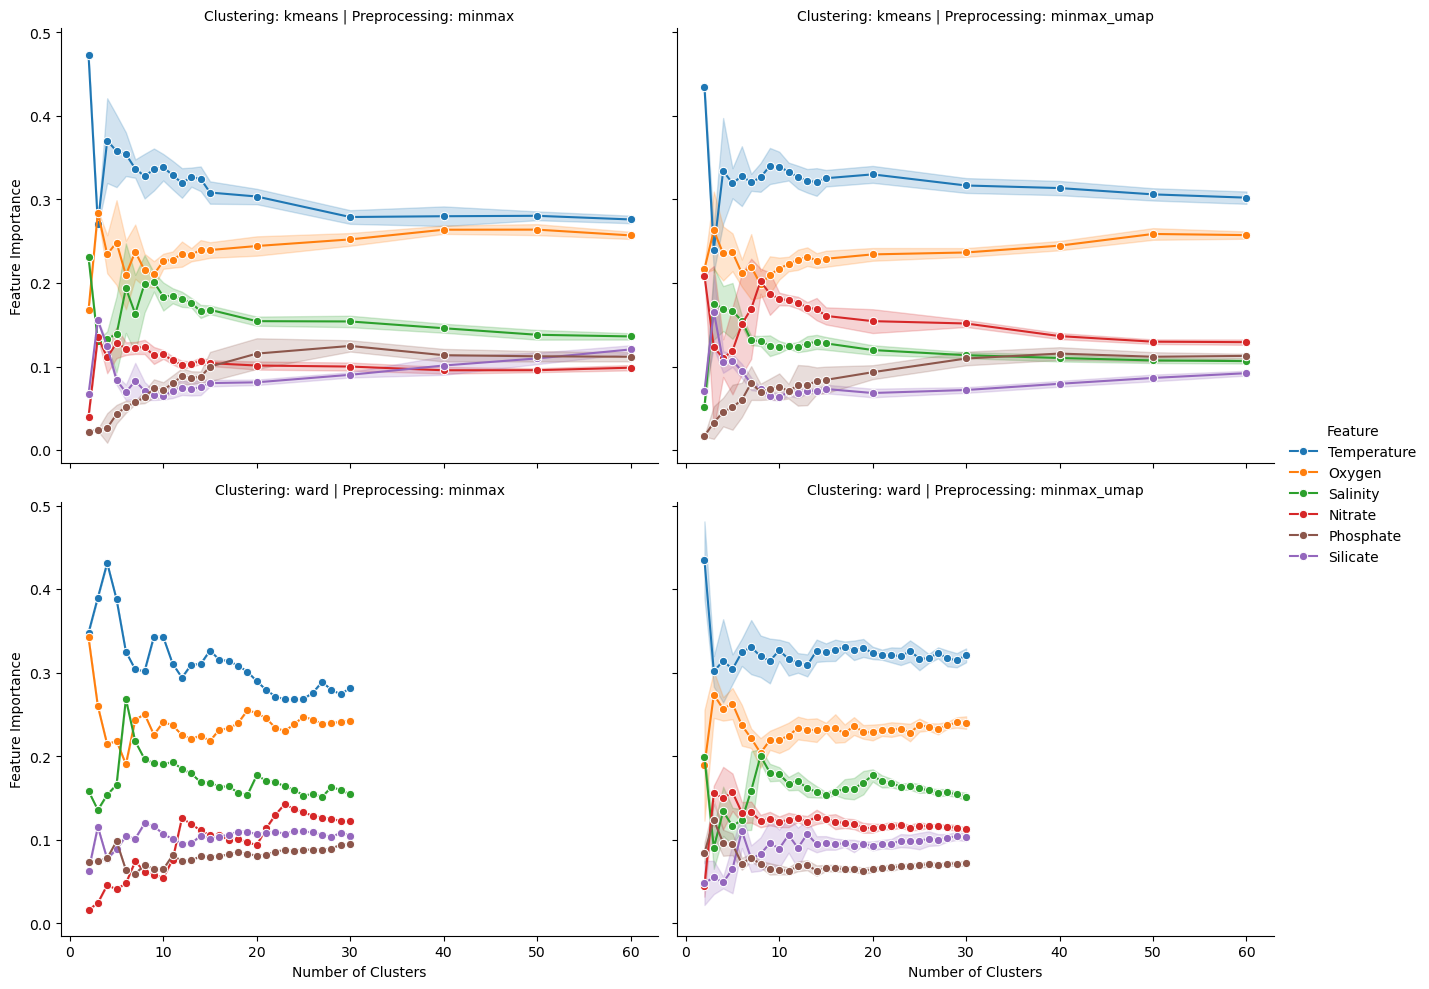

In [6]:
# Create a FacetGrid with two facets: one for preprocessing and one for clustering
g = sns.FacetGrid(fi, col="preprocessing", row="clustering", height=5, aspect=1.3, sharey=True)

# Plot with confidence intervals (standard deviation)
g.map(sns.lineplot, "n_clusters", "importance", "parameter", marker="o", errorbar="sd")

# Adjust legend and titles
g.add_legend(title="Feature")
g.set_axis_labels("Number of Clusters", "Feature Importance")
g.set_titles(col_template="Preprocessing: {col_name}", row_template="Clustering: {row_name}")

# Show plot
plt.show()

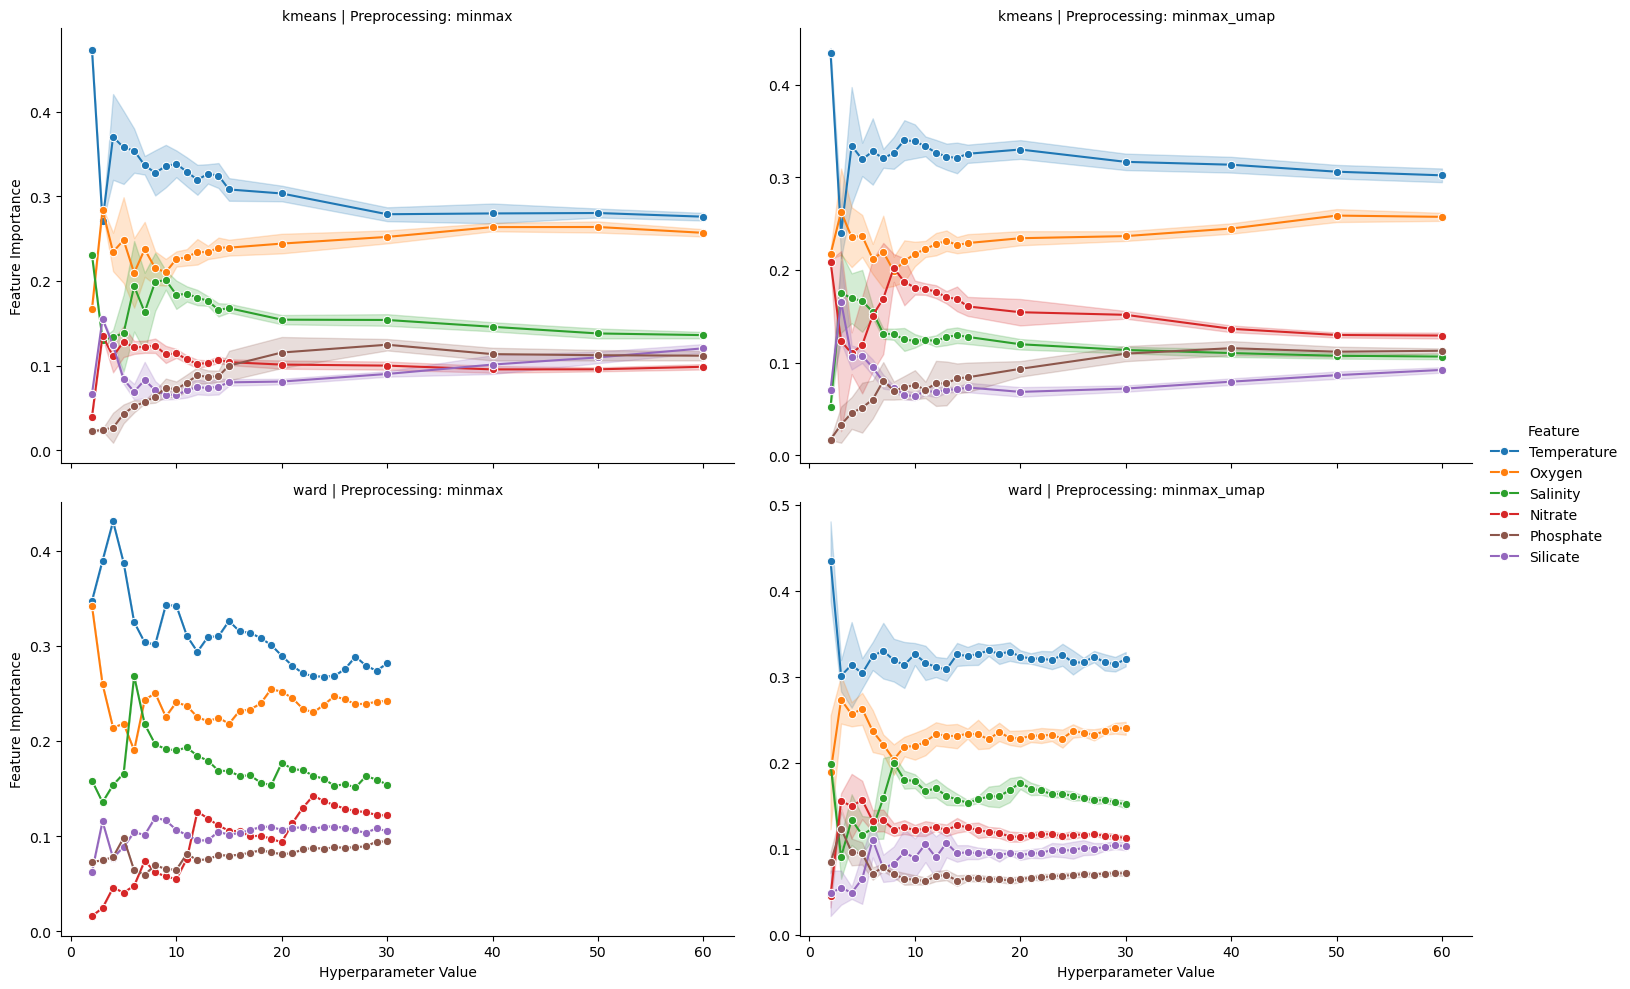

In [12]:
# Custom function to set the x-axis variable based on the clustering algorithm
def plot_func(data, **kwargs):
    # For KMeans/Ward, use 'n_clusters' on x-axis
    if data['clustering'].iloc[0] in ['kmeans', 'ward']:
        x_var = "n_clusters"
    # For DBSCAN, check the 'hyperparameter' to set the appropriate x-axis
    elif data['clustering'].iloc[0] == 'dbscan':
        if 'eps' in data['parameter'].values:
            x_var = "eps"
        else:
            x_var = "min_samples"
    
    sns.lineplot(data=data, x=x_var, y="importance", hue="parameter", marker="o", errorbar="sd", **kwargs)


# Create the new 'hyperparameter' column for DBSCAN specific hyperparameters (eps, min_samples)
fi["hyperparameter"] = fi.apply(
    lambda row: f"{row['clustering']} - {row['parameter']}" if row['clustering'] == 'dbscan' 
    else f"{row['clustering']}", axis=1)

# Set up the FacetGrid for the plotting
g = sns.FacetGrid(fi, col="preprocessing", row="hyperparameter", height=5, aspect=1.5, sharey=False)

# Map the custom plotting function
g.map_dataframe(plot_func)

# Adjust the titles, labels, and legend
g.set_axis_labels("Hyperparameter Value", "Feature Importance")
g.set_titles(col_template="Preprocessing: {col_name}", row_template="{row_name}")
g.add_legend(title="Feature")

# Show the plot
plt.show()


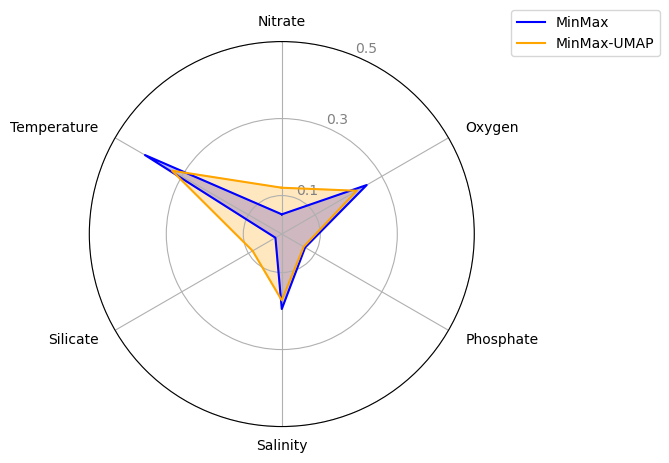

In [46]:
# Spider plot for final hyperparameter combinations

# Concat all feature importances from final hyperparameter combinations
temp = pd.concat([fi.query(get_query_string_hyps_filter(hyp_config.kmeans_original_hyps, preproc="minmax", algorithm="kmeans", float_tol=1e-8)),
                  fi.query(get_query_string_hyps_filter(hyp_config.kmeans_umap_hyps, preproc="minmax_umap", algorithm="kmeans", float_tol=1e-8)),
                  fi.query(get_query_string_hyps_filter(hyp_config.ward_original_hyps, preproc="minmax", algorithm="ward", float_tol=1e-8)),
                  fi.query(get_query_string_hyps_filter(hyp_config.ward_umap_hyps, preproc="minmax_umap", algorithm="ward", float_tol=1e-8)),
                  # fi.query(get_query_string_hyps_filter(hyp_config.dbscan_original_hyps, preproc="minmax", algorithm="dbscan", float_tol=1e-8)),
                  # fi.query(get_query_string_hyps_filter(hyp_config.dbscan_umap_hyps, preproc="minmax_umap", algorithm="dbscan", float_tol=1e-8))
                 ])

# Compute mean importance by data type
radar_data = temp[['parameter', 'importance', 'preprocessing']].groupby(["parameter", "preprocessing"]).mean().reset_index()
radar_original = radar_data[radar_data["preprocessing"] == "minmax"].set_index("parameter")["importance"]
radar_embedded = radar_data[radar_data["preprocessing"] == "minmax_umap"].set_index("parameter")["importance"]

# Radar chart preparation
categories = radar_original.index.tolist()
num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

# Plot
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
ax.plot(angles, radar_original.tolist() + radar_original[:1].tolist(), label="MinMax", color="blue")
ax.fill(angles, radar_original.tolist() + radar_original[:1].tolist(), alpha=0.25, color="blue")
ax.plot(angles, radar_embedded.tolist() + radar_embedded[:1].tolist(), label="MinMax-UMAP", color="orange")
ax.fill(angles, radar_embedded.tolist() + radar_embedded[:1].tolist(), alpha=0.25, color="orange")

# Formatting
# ax.set_title("Feature Importance Distribution: Original vs. Embedded Data")#, size=10, pad=20)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, ha='center')  # You can change fontsize or alignment for clarity

# Use external padding for labels
for label, angle in zip(ax.get_xticklabels(), angles):
    if angle in (0, np.pi):  # Top and bottom labels
        label.set_verticalalignment('center')
    elif 0 < angle < np.pi:  # Right-side labels
        label.set_horizontalalignment('left')
    else:  # Left-side labels
        label.set_horizontalalignment('right')
        
ax.set_yticks([0.1, 0.3, 0.5])
ax.set_yticklabels(["0.1", "0.3", "0.5"], color="gray")#, size=10)
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1.1))

#plt.tight_layout()
# plt.savefig(f"{output_dir_high_res}feature_importance_data_comparison.png", bbox_inches="tight", dpi=1000)
plt.show()


## KMeans

In [30]:
# Mean feature importances for KMeans 
query_str = get_query_string_hyps_filter(hyp_config.kmeans_original_hyps, preproc="minmax", algorithm="kmeans", float_tol=1e-8)
fi.query(query_str)[["importance", "oob", "parameter"]].groupby(["parameter"]).mean()

,importance,oob
parameter,,
Nitrate,0.039729,0.9965
Oxygen,0.167138,0.9965
Phosphate,0.066700,0.9965
Salinity,0.230924,0.9965
Silicate,0.022257,0.9965
Temperature,0.473253,0.9965


In [31]:
# Mean feature importances for KMeans on the embedding
query_str = get_query_string_hyps_filter(hyp_config.kmeans_umap_hyps, preproc="minmax_umap", algorithm="kmeans", float_tol=1e-8)
fi.query(query_str)[["importance", "oob", "parameter"]].groupby(["parameter"]).mean()

,importance,oob
parameter,,
Nitrate,0.123399,0.983418
Oxygen,0.217240,0.983418
Phosphate,0.063568,0.983418
Salinity,0.180925,0.983418
Silicate,0.075983,0.983418
Temperature,0.338884,0.983418


## Ward

In [32]:
# Mean feature importances for Ward 
query_str = get_query_string_hyps_filter(hyp_config.ward_original_hyps, preproc="minmax", algorithm="ward", float_tol=1e-8)
fi.query(query_str)[["importance", "oob", "parameter"]].groupby(["parameter"]).mean()

,importance,oob
parameter,,
Nitrate,0.062680,0.996308
Oxygen,0.342185,0.996308
Phosphate,0.073033,0.996308
Salinity,0.158481,0.996308
Silicate,0.015986,0.996308
Temperature,0.347634,0.996308


In [33]:
# Mean feature importances for Ward on the embedding
query_str = get_query_string_hyps_filter(hyp_config.ward_umap_hyps, preproc="minmax_umap", algorithm="ward", float_tol=1e-8)
fi.query(query_str)[["importance", "oob", "parameter"]].groupby(["parameter"]).mean()

,importance,oob
parameter,,
Nitrate,0.117238,0.974471
Oxygen,0.232635,0.974471
Phosphate,0.068094,0.974471
Salinity,0.163476,0.974471
Silicate,0.099030,0.974471
Temperature,0.319528,0.974471


## DBSCAN

In [34]:
# Mean feature importances for DBSCAN 
query_str = get_query_string_hyps_filter(hyp_config.dbscan_original_hyps, preproc="minmax", algorithm="dbscan", float_tol=1e-8)
fi.query(query_str)[["importance", "oob", "parameter"]].groupby(["parameter"]).mean()

UndefinedVariableError: name 'eps' is not defined

In [ ]:
# Mean feature importances for DBSCAN on the embedding
query_str = get_query_string_hyps_filter(hyp_config.dbscan_umap_hyps, preproc="minmax_umap", algorithm="dbscan", float_tol=1e-8)
fi.query(query_str)[["importance", "oob", "parameter"]].groupby(["parameter"]).mean()

In [ ]:
# On original data
eps = hyp_config.dbscan_original_hyps["eps"]
min_samples = hyp_config.dbscan_original_hyps["min_samples"]
preprocessing = "minmax"

# Get labels
temp = df_dbscan[(df_dbscan.eps.round(8) == round(eps, 8)) & (df_dbscan.min_samples == min_samples) & (df_dbscan.preprocessing == preprocesing)][["label", "LATITUDE", "LONGITUDE", "LEV_M"]]

# Add parameter information
# temp = df_total.merge(filtered, on=["LATITUDE", "LONGITUDE", "LEV_M"], how="outer")
print(len(temp) == 49030)

In [ ]:
rf_dbscan_original = rf(temp, x_columns=x_cols)
rf_dbscan_original

In [ ]:
# On embedded data
eps = hyp_config.dbscan_umap_hyps["eps"]
min_samples = hyp_config.dbscan_umap_hyps["min_samples"]
preprocessing = "minmax_umap"

# Get labels
temp = df_dbscan[(df_dbscan.eps.round(8) == round(eps, 8)) & (df_dbscan.min_samples == min_samples) & (df_dbscan.preprocessing == preprocesing)][["label", "LATITUDE", "LONGITUDE", "LEV_M"]]

# Add parameter information
# temp = df_total.merge(filtered, on=["LATITUDE", "LONGITUDE", "LEV_M"], how="outer")
print(len(temp) == 49030)

In [ ]:
rf_dbscan_embedding = rf(temp, x_columns=x_cols)
rf_dbscan_embedding

## Final clustering (NEMI)

In [ ]:
df_final = pd.read_csv(f"{config.output_dir_nemi}/volume_nemi_iteration67.csv").drop(["label", "sorted_label"], axis=1).rename(columns={"label_color": "color", "final_label": "label"})

In [ ]:
# Get labels
temp = df_final[["label", "LATITUDE", "LONGITUDE", "LEV_M"]]

# Add parameter information
# temp = df_total.merge(filtered, on=["LATITUDE", "LONGITUDE", "LEV_M"], how="outer")
print(len(temp) == 49030)

In [ ]:
rf_final = rf(temp, x_columns=x_cols)
rf_final

In [ ]:
# Concatenate results
algorithms = ["kmeans", "kmeans", "ward", "ward", "dbscan", "dbscan", "nemi"]
data_array = ["minmax", "minmax_umap", "minmax", "minmax_umap", "minmax", "minmax_umap", "minmax_umap"]

In [ ]:
df_rf = pd.DataFrame(columns=["algorithm", "data", "parameter", "f", "p"])

rows = []
for temp, algo, data in zip([rf_kmeans_original, rf_kmeans_embedding, rf_ward_original, rf_ward_embedding, rf_dbscan_original, rf_dbscan_embedding, rf_final], 
                          algorithms, data_array):
    temp["algorithm"] = algo
    temp["data"] = data
    rows.append(temp)

df_rf = pd.concat(rows).reset_index(drop=True)

In [ ]:
df_rf.to_csv(output_dir + "feature_importance.csv", index=False)

## Visualisation

In [ ]:
# Viz
df_rf = pd.read_csv("feature_importance.csv")
df_rf['parameter'] = df_rf['parameter'].replace({'P_TEMPERATURE_scaled': 'Temperature', 'P_SALINITY_scaled': 'Salinity', 'P_OXYGEN_scaled': 'Oxygen',
                           'P_NITRATE_scaled': 'Nitrate', 'P_SILICATE_scaled': 'Silicate', 'P_PHOSPHATE_scaled': 'Phosphate'})

In [ ]:
heatmap_data = df_rf.pivot_table(index="parameter", columns=["algorithm", "data"], values="importance", aggfunc="mean")

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", cbar_kws={'label': 'Importance'})
plt.title("Heatmap of Feature Importance by Algorithm and Data Type")
plt.xlabel("Algorithm and Data Type")
plt.ylabel("Features")
plt.show()

In [ ]:
temp = df_rf[df_rf.algorithm != "nemi"]

# Compute mean importance by data type
radar_data = temp[['parameter', 'importance', 'data']].groupby(["parameter", "data"]).mean().reset_index()
radar_original = radar_data[radar_data["data"] == "original"].set_index("parameter")["importance"]
radar_embedded = radar_data[radar_data["data"] == "embedding"].set_index("parameter")["importance"]

# Radar chart preparation
categories = radar_original.index.tolist()
num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

# Plot
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
ax.plot(angles, radar_original.tolist() + radar_original[:1].tolist(), label="Original Data", color="blue")
ax.fill(angles, radar_original.tolist() + radar_original[:1].tolist(), alpha=0.25, color="blue")
ax.plot(angles, radar_embedded.tolist() + radar_embedded[:1].tolist(), label="Embedded Data", color="orange")
ax.fill(angles, radar_embedded.tolist() + radar_embedded[:1].tolist(), alpha=0.25, color="orange")

# Formatting
# ax.set_title("Feature Importance Distribution: Original vs. Embedded Data")#, size=10, pad=20)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, ha='center')  # You can change fontsize or alignment for clarity

# Use external padding for labels
for label, angle in zip(ax.get_xticklabels(), angles):
    if angle in (0, np.pi):  # Top and bottom labels
        label.set_verticalalignment('center')
    elif 0 < angle < np.pi:  # Right-side labels
        label.set_horizontalalignment('left')
    else:  # Left-side labels
        label.set_horizontalalignment('right')
        
ax.set_yticks([0.1, 0.3, 0.5])
ax.set_yticklabels(["0.1", "0.3", "0.5"], color="gray")#, size=10)
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1.1))

#plt.tight_layout()
plt.savefig(f"{output_dir_high_res}feature_importance_data_comparison.png", bbox_inches="tight", dpi=1000)
plt.show()